In [12]:
import sys
sys.path.append('./src')
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')
import importlib
from dl_utils import *

# Activation Functions

Each cell below shows one activation function plotted alongside its derivative (dashed line).
The derivative is computed using the Operation's own `backward()` method — the same code used during training.

---
## Sigmoid

**Formula**: `σ(x) = 1 / (1 + exp(-x))`

**Pros:**
- Output is bounded in (0, 1) — useful for probabilities
- Smooth and differentiable everywhere

**Cons:**
- **Vanishing gradients**: derivative peaks at 0.25 and decays to 0 for large |x| — gradients shrink to near-zero in deep networks, stalling learning
- Outputs are not zero-centered (always positive), which can slow convergence
- Computationally more expensive than ReLU

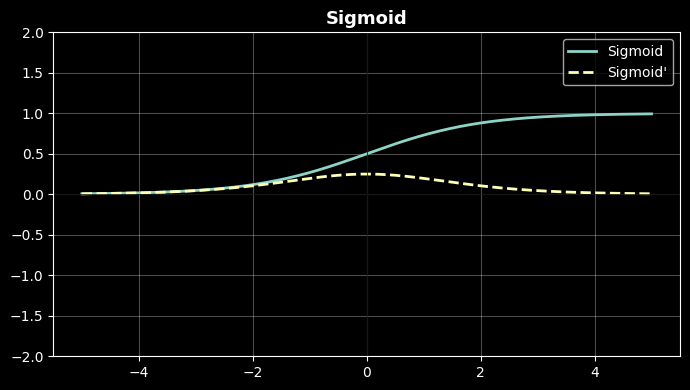

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_activation(Sigmoid(), 'Sigmoid', ax=ax)
plt.tight_layout()
plt.show()

---
## Tanh

**Formula**: `tanh(x) = (exp(x) - exp(-x)) / (exp(x) + exp(-x))`

**Pros:**
- Output is bounded in (-1, 1) and **zero-centered** — fixes the non-centered issue of Sigmoid
- Stronger gradients than Sigmoid (derivative peaks at 1)
- Often preferred over Sigmoid for hidden layers in RNNs

**Cons:**
- Still suffers from **vanishing gradients** for large |x|
- More expensive to compute than ReLU

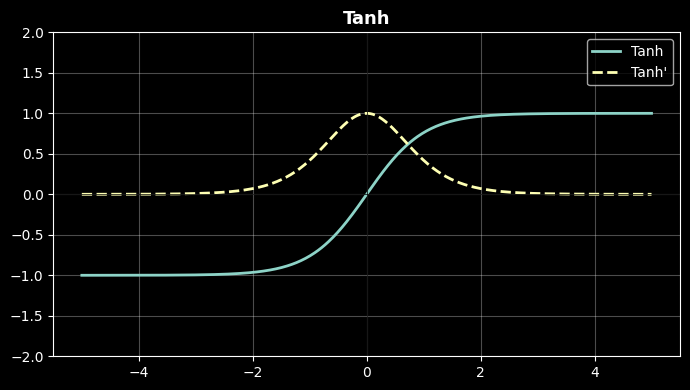

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_activation(Tanh(), 'Tanh', ax=ax)
plt.tight_layout()
plt.show()

---
## ReLU

**Formula**: `ReLU(x) = max(0, x)`

**Pros:**
- No vanishing gradient for positive inputs (derivative is exactly 1)
- Very fast to compute
- Induces sparsity — only a subset of neurons activate, which can act as implicit regularization
- Default choice for hidden layers in feedforward networks

**Cons:**
- **Dying ReLU**: neurons receiving consistently negative inputs output 0 forever — their gradient is 0 and they stop learning entirely
- Not zero-centered
- Derivative is undefined at exactly x=0 (in practice, we set it to 0 or 1)

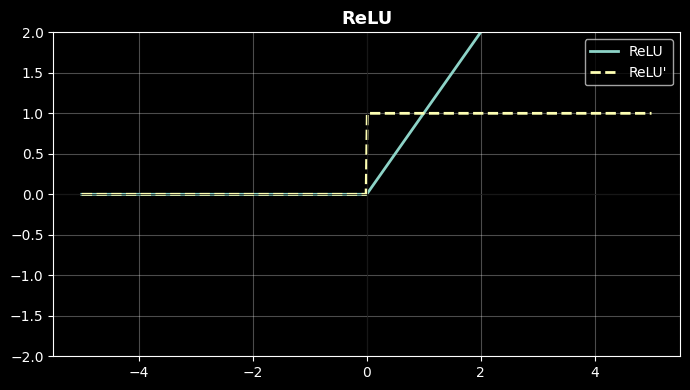

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_activation(ReLU(), 'ReLU', ax=ax)
plt.tight_layout()
plt.show()

---
## Leaky ReLU

**Formula**: `LeakyReLU(x) = x if x > 0 else α * x` (typically α = 0.01)

**Pros:**
- Fixes the **dying ReLU** problem — negative inputs still produce a small non-zero gradient (α)
- As fast as ReLU to compute
- Simple fix with minimal added complexity

**Cons:**
- α is a hyperparameter — results can be sensitive to its value
- Still not zero-centered
- The benefit over ReLU is not always consistent across tasks

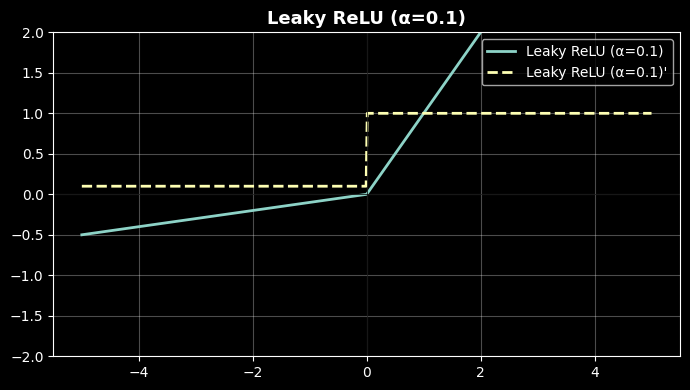

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_activation(LeakyReLU(alpha=0.1), 'Leaky ReLU (α=0.1)', ax=ax)
plt.tight_layout()
plt.show()

---
## ELU

**Formula**: `ELU(x) = x if x > 0 else α * (exp(x) - 1)` (typically α = 1.0)

**Pros:**
- Smooth for all inputs including negative — no sharp kink at 0 like ReLU/Leaky ReLU
- Mean activations are closer to zero than ReLU, which speeds up learning
- Saturates to −α for very negative inputs, reducing sensitivity to outliers

**Cons:**
- More expensive to compute than ReLU due to `exp()`
- α is a hyperparameter
- Can still produce vanishing gradients for very negative inputs (saturates at −α)

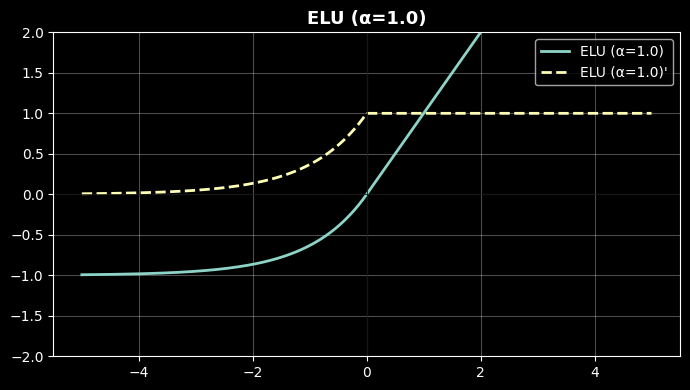

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_activation(ELU(alpha=1.0), 'ELU (α=1.0)', ax=ax)
plt.tight_layout()
plt.show()

---
## Swish (SiLU)

**Formula**: `Swish(x) = x * σ(x)` where σ is the Sigmoid

**Pros:**
- Smooth and non-monotonic — can model more complex patterns than ReLU
- Empirically outperforms ReLU on deeper networks (used in EfficientNet, etc.)
- Self-gated: the sigmoid acts as a learned gate on the identity

**Cons:**
- More expensive to compute than ReLU
- Non-monotonic behavior (slight dip before 0) can sometimes cause instability
- Less interpretable than simpler functions

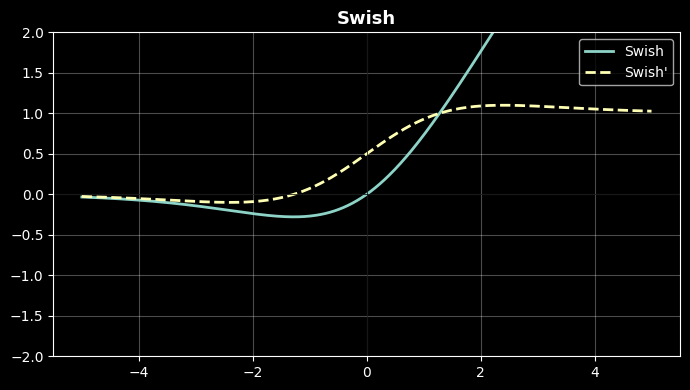

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_activation(Swish(), 'Swish', ax=ax)
plt.tight_layout()
plt.show()

---
## All Functions — Side by Side

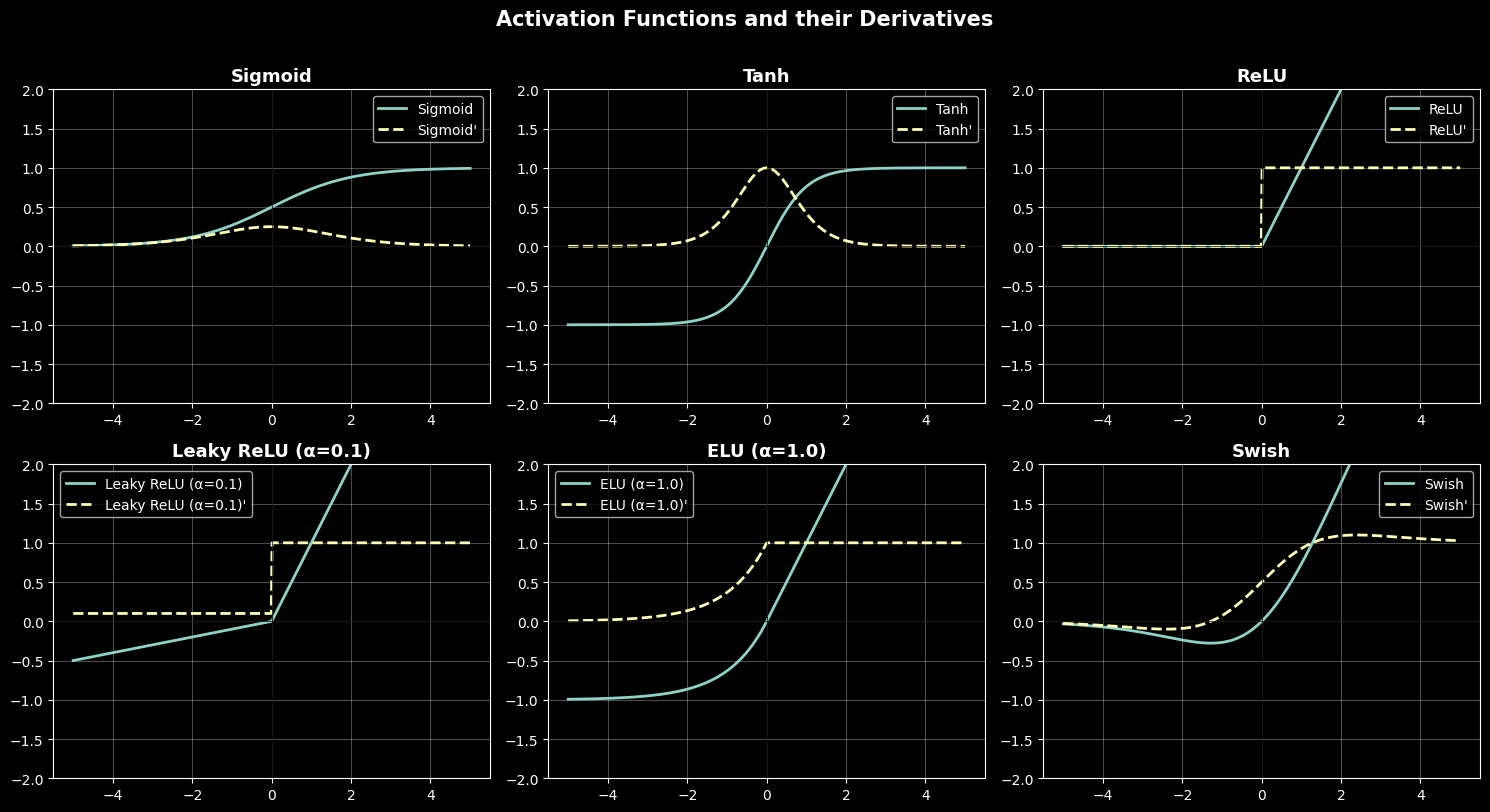

In [19]:
activations = [
    (Sigmoid(),          'Sigmoid'),
    (Tanh(),             'Tanh'),
    (ReLU(),             'ReLU'),
    (LeakyReLU(0.1),     'Leaky ReLU (α=0.1)'),
    (ELU(1.0),           'ELU (α=1.0)'),
    (Swish(),            'Swish'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (activation, name) in zip(axes.flatten(), activations):
    plot_activation(activation, name, ax=ax)

plt.suptitle('Activation Functions and their Derivatives', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()